# 03 — Correlation and cross-correlation

**Dataset:** `drive_day_2026`

**Question:** Which channels show consistent recurrence periods and sensor lags?

## Method

Compute overlap-normalized channel autocorrelation and pairwise cross-correlation within bounded lag ranges.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_classical import render_correlation_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "drive_day_2026"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,07173121b1534f1eadb8b127005d4eff70872388074c2b...,21.9,moving_candidate,False,recorded_time_column,train
1,1a8433bf1168531d6f7c2deb5c37b27de5ddf1d9f65316...,21.9,moving_candidate,False,recorded_time_column,train
2,1cca7c275163fc193899535ebb0c13f26676e8568d3c8a...,37.9,moving_candidate,False,recorded_time_column,train
3,200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c7...,57.8,moving_candidate,False,recorded_time_column,train
4,25aa01e1dcbaea32c062e01b0f782c938c34163fc58af1...,73.7,moving_candidate,False,recorded_time_column,train
5,2f775054c4e7bb342cf49e0ee66406e82353c274c103fc...,25.9,moving_candidate,False,recorded_time_column,train
6,382db1f8ede73f956341d7b461790125339762ec9d7cc9...,57.8,stationary_candidate,True,recorded_time_column,train
7,4c8d0190b666e26315ce16c862ca2e968d576e14537487...,21.9,moving_candidate,False,recorded_time_column,train
8,554af5ad576c1c1d069356649e3bd1e2699a5801f6a0fa...,17.9,stationary_candidate,True,recorded_time_column,train
9,564a12f3d813c10242613a907d2b4981e7296739ba9a56...,57.8,stationary_candidate,True,recorded_time_column,train


In [2]:
EXPERIMENT_OPTIONS = {}
EXPERIMENT_OPTIONS

{}

,task,split,metric,value,sample_count,reference_source
0,channel_lag_consensus,train,mean_lag_mad_s,1.033333,9,none
1,channel_lag_consensus,validation,mean_lag_mad_s,0.800000,3,none
2,channel_lag_consensus,test,mean_lag_mad_s,0.000000,3,none
3,channel_lag_consensus,all,mean_lag_mad_s,0.780000,15,none
4,sensor_cross_correlation,train,median_absolute_peak_correlation,0.795943,111,none
5,sensor_cross_correlation,validation,median_absolute_peak_correlation,0.733258,20,none
6,sensor_cross_correlation,test,median_absolute_peak_correlation,0.768556,30,none
7,sensor_cross_correlation,all,median_absolute_peak_correlation,0.765724,161,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,51,15,5e9e04831922d971561f6ffb53b2c77744d905cca01dcc...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,51,5,MC Duty Cycle [%],13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lag_s,51.0,NaN,NaN,NaN,32.003922,26.214919,15.1,16.75,20.6,40.95,105.9
correlation,51.0,NaN,NaN,NaN,0.179163,0.345962,-0.953213,0.092444,0.190022,0.289726,0.928985
segment_id,51,5,channel_0,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,51.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
end_s,51.0,NaN,NaN,NaN,78.160784,53.190721,33.8,41.8,57.8,85.7,229.1
prediction_kind,51,1,channel_recurrence_period,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,51.0,NaN,NaN,NaN,0.179163,0.345962,-0.953213,0.092444,0.190022,0.289726,0.928985
label_status,51,1,provisional_unverified,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,median,std,min,max
recording_id,,,,,,
6faa006353747cbeb4e6d2e90954728110cb94fabfcd41e319270d4cde22f117,5,0.792087,0.745454,0.105161,0.679272,0.928985
6939b3836a088e9113eb3bffcf362bed963a71bbd9012ecb56dc61e6d500da39,5,0.321952,0.392503,0.145091,0.130630,0.468306
e57d3de89d6f2a3165aa05beee7b611f60923e090254337c1b48f744c78db52d,5,0.260608,0.293818,0.178519,-0.025823,0.465752
5e9e04831922d971561f6ffb53b2c77744d905cca01dcc2fe043d10b2f63c613,5,0.160085,0.238009,0.225465,-0.172738,0.355750
667a6e15a4394db30d7cce7a4db319041453bfa306b566a87e84b213d81efb29,5,0.209682,0.229047,0.058788,0.131715,0.277564
25aa01e1dcbaea32c062e01b0f782c938c34163fc58af14087dfe2f77906c06e,4,-0.005961,0.182843,0.438467,-0.659409,0.269878
629d7d57091b71c5c0c2c6f42218702e454b4ae60e20636885741c7c22fe1bb4,5,0.061774,0.176364,0.287119,-0.437239,0.285633
f8a2dfe19bc591bed40778fcb493d9a34a3261518b2f4b416ba15a9402ec6dd7,3,0.164609,0.162457,0.017112,0.148675,0.182695
200a690cbeb5a4d9f415d6a933e60aa13a0cf5ee5c03c71731d7739c8ecbda5e,4,0.154486,0.153829,0.093401,0.059688,0.250600


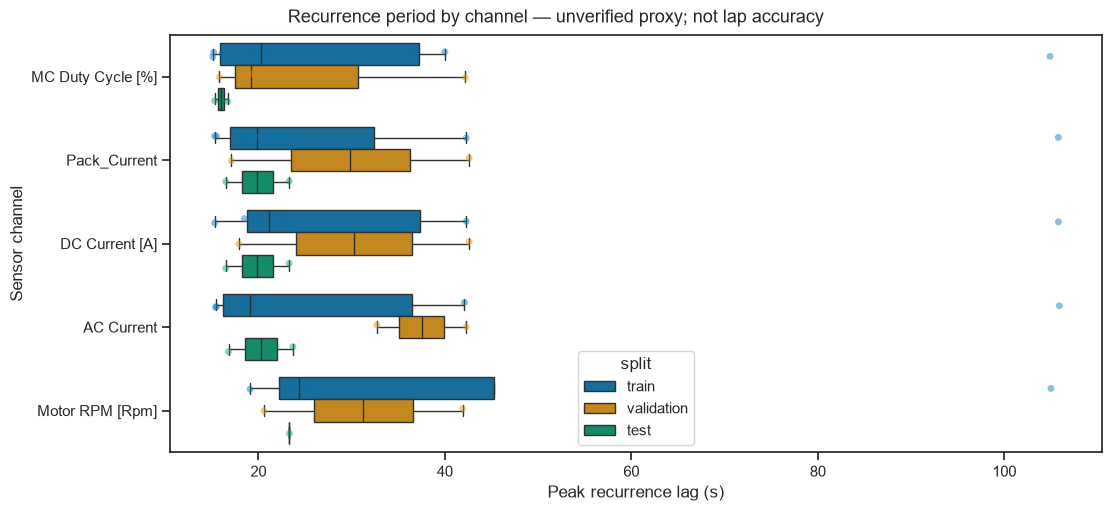

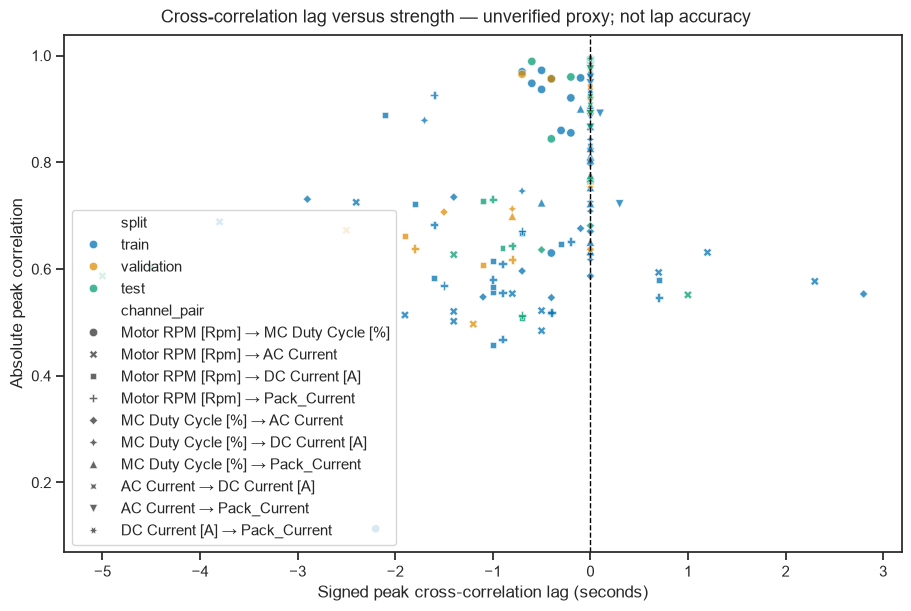

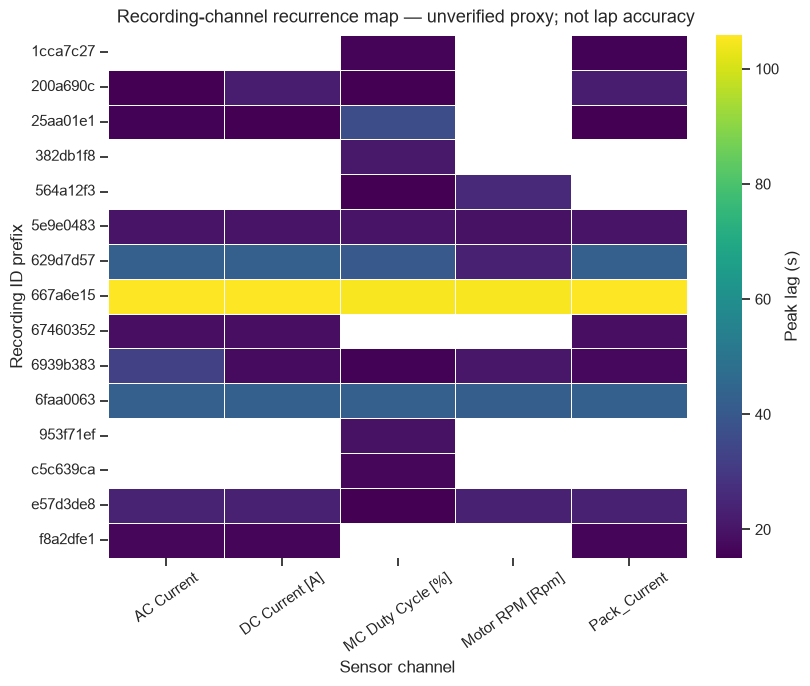

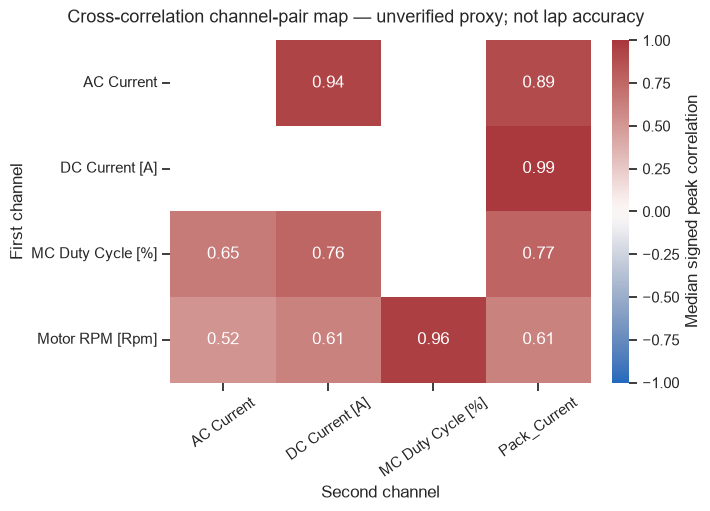

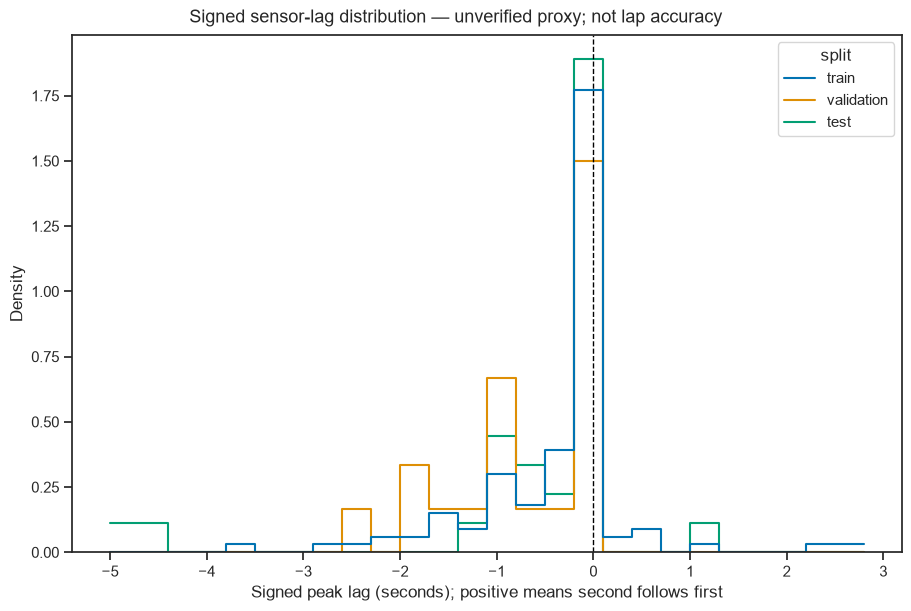

In [3]:
METHOD = "03_correlation"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_correlation_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,4.063
clock_provenance,recorded_time_column
sample_rate_hz,10.0
channels,"[Motor RPM [Rpm], MC Duty Cycle [%], AC Curren..."
label_provenance,unverified_channel_recurrence


## Reading

Low lag disagreement means channel consistency. Coupled sensors are not independent lap evidence.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.